In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data_complete.csv")

In [4]:
df.shape

(7955, 61)

In [5]:
df.head()

,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cum_avg,...,SOH,SOH(-30EFC),SOH(-60EFC),SOH(-90EFC),SOH(-120EFC),delta_SOH(-30EFC),delta_SOH(-60EFC),delta_SOH(-90EFC),delta_SOH(-120EFC),RUL_EFC
0,battery00,True,7424.475,1.001191,17.149865,0.035325,0.189894,0.278888,0.400940,26.569209,...,100.000000,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,0.000000,150.411108
1,battery00,False,12219.679,1.995107,32.833935,0.038305,0.190357,0.282313,0.403624,32.363611,...,99.788050,100.0,100.0,100.0,100.0,0.211950,0.211950,0.211950,0.211950,149.417193
2,battery00,False,17025.679,2.992049,48.630552,0.041295,0.190822,0.285749,0.406316,35.243437,...,99.575454,100.0,100.0,100.0,100.0,0.424546,0.424546,0.424546,0.424546,148.420251
3,battery00,False,21836.339,3.987183,64.388980,0.044280,0.191287,0.289179,0.409004,36.865746,...,99.363243,100.0,100.0,100.0,100.0,0.636757,0.636757,0.636757,0.636757,147.425116
4,battery00,False,29014.698,4.976644,79.798714,0.047247,0.191748,0.292589,0.411676,34.856287,...,99.152243,100.0,100.0,100.0,100.0,0.847757,0.847757,0.847757,0.847757,146.435656


In [6]:
df.columns.tolist()

['batt_label',
 'isRefCycle',
 'time_sec',
 'EFC',
 'E_cum_Wh',
 'Q_norm_at_3.9_V',
 'Q_norm_at_3.8_V',
 'Q_norm_at_3.7_V',
 'Q_norm_at_3.6_V',
 'T_cum_avg',
 'T_cum_max',
 'T_cum_min',
 'T_cycle_avg',
 'T_cycle_max',
 'T_cycle_min',
 'sec_T_over_30',
 'sec_T_over_40',
 'sec_T_over_45',
 'sec_T_over_50',
 'sec_T_over_60',
 'sec_T_st_-20',
 'sec_T_-20_0',
 'sec_T_0_15',
 'sec_T_15_30',
 'sec_T_30_45',
 'sec_T_45_60',
 'sec_T_60_80',
 'sec_T_gt_80',
 'C_rate_cum_avg',
 'C_rate_cum_max',
 'C_rate_cycle_avg',
 'C_rate_cycle_max',
 'sec_C_rate_0_0.5',
 'sec_C_rate_0.5_1',
 'sec_C_rate_1_2',
 'sec_C_rate_2_3',
 'sec_C_rate_3_4',
 'sec_C_rate_4_5',
 'sec_C_rate_5_6',
 'sec_C_rate_6_7',
 'sec_C_rate_gt_7',
 'sec_at_high_voltage',
 'sec_at_low_voltage',
 'integral_high_volt_high_temp',
 'integral_low_volt_high_temp',
 'integral_low_volt_high_discharge',
 'integral_high_temp_high_discharge',
 'integral_low_temp_high_discharge',
 'integral_discharge_squared',
 'integral_discharge_squared_T',
 'R_

In [7]:
df["batt_label"].unique()

array(['battery00', 'battery01', 'battery10', 'battery11', 'battery20',
       'battery21', 'battery22', 'battery23', 'battery30', 'battery31',
       'battery40', 'battery41', 'battery50', 'battery51', 'battery52',
       'battery02', 'battery03', 'battery12', 'battery24', 'battery25',
       'battery32', 'battery33', 'battery53'], dtype=object)

In [8]:
df["SOH"].describe()

count    7955.000000
mean       86.041084
std         6.830254
min        68.515261
25%        80.403660
50%        85.649734
75%        91.412713
max       100.000000
Name: SOH, dtype: float64

In [9]:
[col for col in df.columns if "efc" in col.lower() or "cycle" in col.lower() or "rul" in col.lower()]

['isRefCycle',
 'EFC',
 'T_cycle_avg',
 'T_cycle_max',
 'T_cycle_min',
 'C_rate_cycle_avg',
 'C_rate_cycle_max',
 'SOH(-30EFC)',
 'SOH(-60EFC)',
 'SOH(-90EFC)',
 'SOH(-120EFC)',
 'delta_SOH(-30EFC)',
 'delta_SOH(-60EFC)',
 'delta_SOH(-90EFC)',
 'delta_SOH(-120EFC)',
 'RUL_EFC']

In [10]:
df["RUL_EFC"].describe()

count    7955.000000
mean      211.907612
std       161.401057
min         0.000000
25%        81.852372
50%       176.512572
75%       304.106940
max       733.306582
Name: RUL_EFC, dtype: float64

In [11]:
df["RUL_EFC"].isna().sum()

np.int64(0)

In [12]:
df[["batt_label", "EFC", "SOH", "RUL_EFC"]].head(20)

,batt_label,EFC,SOH,RUL_EFC
0,battery00,1.001191,100.000000,150.411108
1,battery00,1.995107,99.788050,149.417193
2,battery00,2.992049,99.575454,148.420251
3,battery00,3.987183,99.363243,147.425116
4,battery00,4.976644,99.152243,146.435656
5,battery00,5.963339,98.941832,145.448960
6,battery00,6.951709,98.731064,144.460591
7,battery00,7.937639,98.520816,143.474661
8,battery00,8.921044,98.311107,142.491256
9,battery00,9.902610,98.101790,141.509690


In [13]:
one_batt = "battery00"

df_b = df[df["batt_label"] == one_batt].sort_values("EFC")

df_b[["batt_label", "EFC", "SOH", "RUL_EFC"]].head()

,batt_label,EFC,SOH,RUL_EFC
0,battery00,1.001191,100.000000,150.411108
1,battery00,1.995107,99.788050,149.417193
2,battery00,2.992049,99.575454,148.420251
3,battery00,3.987183,99.363243,147.425116
4,battery00,4.976644,99.152243,146.435656


In [14]:
df_b[["batt_label", "EFC", "SOH", "RUL_EFC"]].tail()

,batt_label,EFC,SOH,RUL_EFC
163,battery00,146.887795,81.942223,4.524505
164,battery00,147.699768,81.863040,3.712531
165,battery00,148.507657,81.784255,2.904643
166,battery00,149.320617,81.704976,2.091683
167,battery00,150.136870,81.625376,1.275429


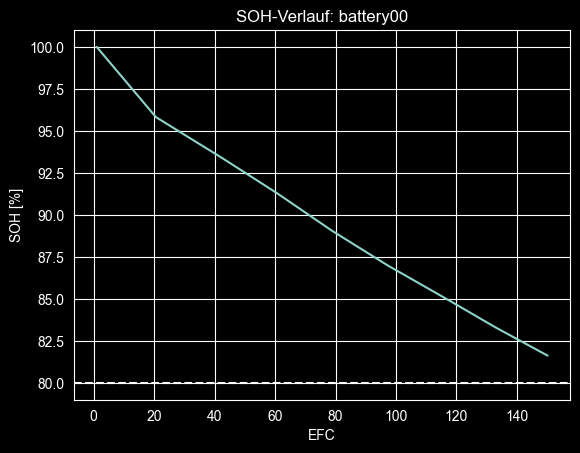

In [15]:
plt.plot(df_b["EFC"], df_b["SOH"])
plt.axhline(80, linestyle="--")
plt.xlabel("EFC")
plt.ylabel("SOH [%]")
plt.title(f"SOH-Verlauf: {one_batt}")
plt.show()

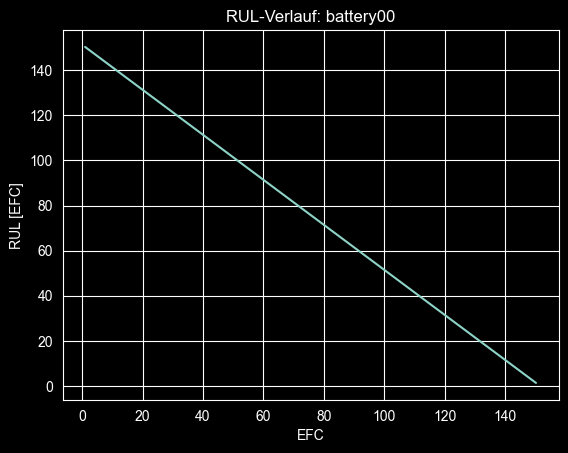

In [16]:
plt.plot(df_b["EFC"], df_b["RUL_EFC"])
plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"RUL-Verlauf: {one_batt}")
plt.show()

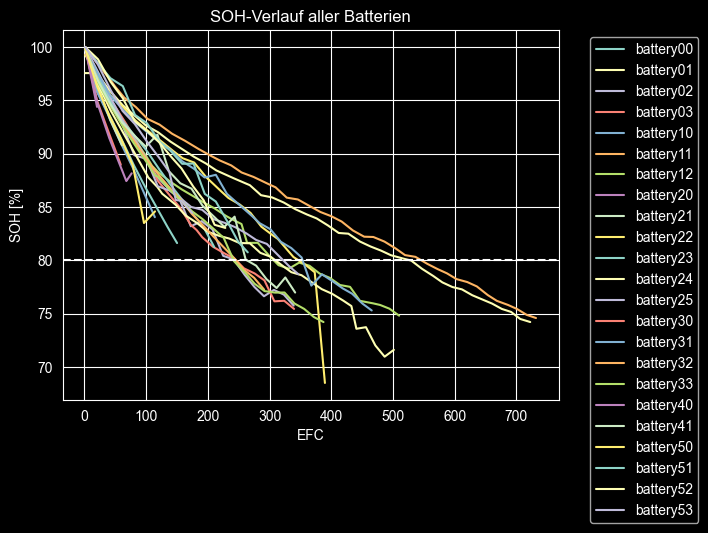

In [17]:
for batt, group in df.groupby("batt_label"):
    group = group.sort_values("EFC")
    plt.plot(group["EFC"], group["SOH"], label=batt)

plt.axhline(80, linestyle="--")
plt.xlabel("EFC")
plt.ylabel("SOH [%]")
plt.title("SOH-Verlauf aller Batterien")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

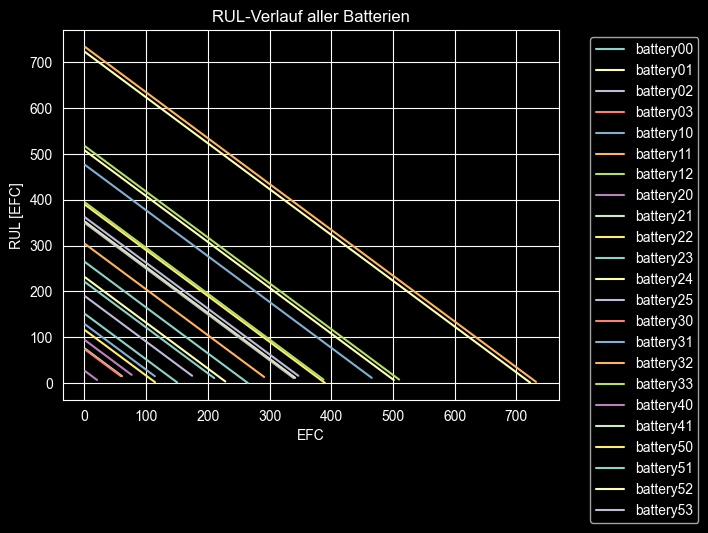

In [18]:
for batt, group in df.groupby("batt_label"):
    group = group.sort_values("EFC")
    plt.plot(group["EFC"], group["RUL_EFC"], label=batt)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("RUL-Verlauf aller Batterien")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [19]:
df["RUL_EFC"].describe()
df["RUL_EFC"].isna().sum()
df[["batt_label", "EFC", "SOH", "RUL_EFC"]].head(20)

,batt_label,EFC,SOH,RUL_EFC
0,battery00,1.001191,100.000000,150.411108
1,battery00,1.995107,99.788050,149.417193
2,battery00,2.992049,99.575454,148.420251
3,battery00,3.987183,99.363243,147.425116
4,battery00,4.976644,99.152243,146.435656
5,battery00,5.963339,98.941832,145.448960
6,battery00,6.951709,98.731064,144.460591
7,battery00,7.937639,98.520816,143.474661
8,battery00,8.921044,98.311107,142.491256
9,battery00,9.902610,98.101790,141.509690


In [20]:
df["batt_label"].nunique()

23

In [21]:
df["batt_label"].value_counts()

batt_label
battery11    861
battery01    859
battery24    613
battery12    612
battery31    548
battery33    464
battery22    443
battery25    401
battery03    401
battery02    400
battery41    397
battery32    337
battery51    295
battery52    253
battery23    232
battery53    190
battery00    168
battery10    126
battery50    125
battery40     82
battery21     64
battery30     63
battery20     21
Name: count, dtype: int64

In [22]:
df_ml = df[["batt_label", "SOH", "RUL_EFC"]].copy()

In [23]:
df_ml = df_ml.dropna()

In [24]:
df_ml.shape
df_ml.head()

,batt_label,SOH,RUL_EFC
0,battery00,100.000000,150.411108
1,battery00,99.788050,149.417193
2,battery00,99.575454,148.420251
3,battery00,99.363243,147.425116
4,battery00,99.152243,146.435656


In [25]:
X = df_ml[["SOH"]]
y = df_ml["RUL_EFC"]
groups = df_ml["batt_label"]

In [26]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

gkf = GroupKFold(n_splits=4)

results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_batteries = df_ml.iloc[test_idx]["batt_label"].unique().tolist()

    results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": test_batteries
    })

results_df = pd.DataFrame(results)
results_df

,fold,MAE,RMSE,R2,test_batteries
0,0,115.308556,158.823729,0.273504,"[battery11, battery41, battery50, battery03, b..."
1,1,123.559558,160.345863,0.243041,"[battery01, battery20, battery22, battery23, b..."
2,2,85.947333,113.492151,0.167273,"[battery00, battery30, battery51, battery24, b..."
3,3,87.013192,114.759095,0.268148,"[battery10, battery21, battery31, battery52, b..."


In [27]:
results_df[["MAE", "RMSE", "R2"]].mean()

MAE     102.957160
RMSE    136.855209
R2        0.237992
dtype: float64

In [28]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gkf = GroupKFold(n_splits=4)

predictions = []
results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": df_ml.iloc[test_idx]["batt_label"].unique().tolist()
    })

    fold_pred = df_ml.iloc[test_idx].copy()
    fold_pred["fold"] = fold
    fold_pred["RUL_pred"] = y_pred
    predictions.append(fold_pred)

results_df = pd.DataFrame(results)
pred_df = pd.concat(predictions, ignore_index=True)

results_df

,fold,MAE,RMSE,R2,test_batteries
0,0,115.308556,158.823729,0.273504,"[battery11, battery41, battery50, battery03, b..."
1,1,123.559558,160.345863,0.243041,"[battery01, battery20, battery22, battery23, b..."
2,2,85.947333,113.492151,0.167273,"[battery00, battery30, battery51, battery24, b..."
3,3,87.013192,114.759095,0.268148,"[battery10, battery21, battery31, battery52, b..."


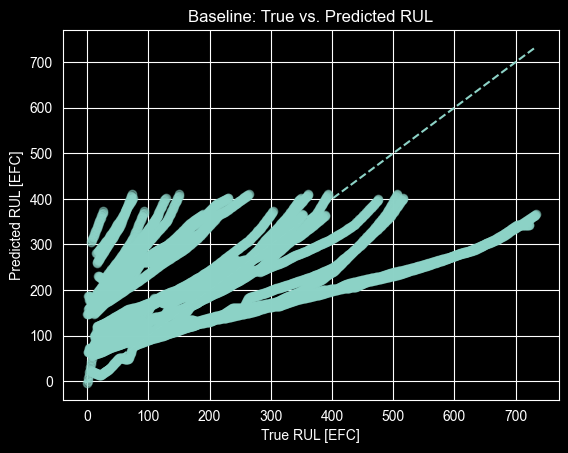

In [29]:
plt.scatter(pred_df["RUL_EFC"], pred_df["RUL_pred"], alpha=0.5)

min_val = min(pred_df["RUL_EFC"].min(), pred_df["RUL_pred"].min())
max_val = max(pred_df["RUL_EFC"].max(), pred_df["RUL_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL [EFC]")
plt.ylabel("Predicted RUL [EFC]")
plt.title("Baseline: True vs. Predicted RUL")
plt.show()

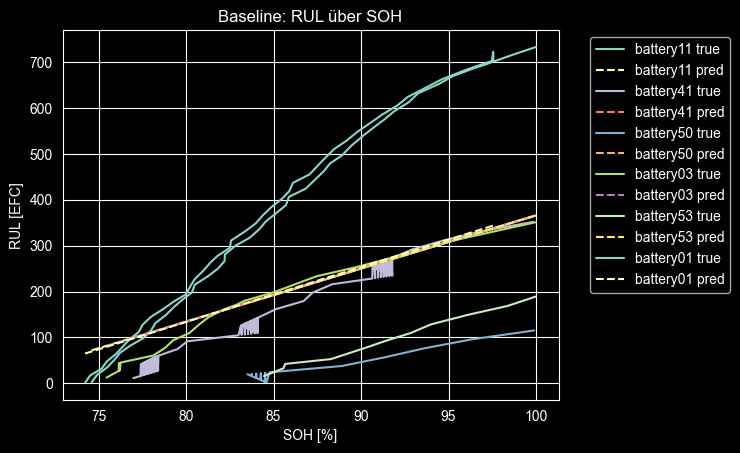

In [30]:
for batt in pred_df["batt_label"].unique()[:6]:
    group = pred_df[pred_df["batt_label"] == batt].copy()
    group = group.sort_values("SOH")

    plt.plot(group["SOH"], group["RUL_EFC"], label=f"{batt} true")
    plt.plot(group["SOH"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")

plt.xlabel("SOH [%]")
plt.ylabel("RUL [EFC]")
plt.title("Baseline: RUL über SOH")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Die SOH-only-Baseline erreicht nur eine begrenzte Vorhersagequalität.
Der mittlere absolute Fehler liegt bei ca. 103 EFC, der RMSE bei ca. 137 EFC.
Das R² von ca. 0.26 zeigt, dass SOH allein nur einen kleinen Teil der RUL-Varianz erklärt.
Daraus folgt, dass zusätzliche Alterungs- und Betriebsfeatures benötigt werden.

In [31]:
#Mit EFC als Feature

df_ml2 = df[["batt_label", "SOH", "EFC", "RUL_EFC"]].copy()
df_ml2 = df_ml2.dropna()

X = df_ml2[["SOH", "EFC"]]
y = df_ml2["RUL_EFC"]
groups = df_ml2["batt_label"]

gkf = GroupKFold(n_splits=4)

results = []
predictions = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "feature_set": "SOH + EFC",
        "model": "LinearRegression",
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": df_ml2.iloc[test_idx]["batt_label"].unique().tolist()
    })

    fold_pred = df_ml2.iloc[test_idx].copy()
    fold_pred["fold"] = fold
    fold_pred["RUL_pred"] = y_pred
    predictions.append(fold_pred)

results_efc_df = pd.DataFrame(results)
pred_efc_df = pd.concat(predictions, ignore_index=True)

results_efc_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,SOH + EFC,LinearRegression,0,108.810978,149.179025,0.359059,"[battery11, battery41, battery50, battery03, b..."
1,SOH + EFC,LinearRegression,1,116.411113,152.477802,0.315505,"[battery01, battery20, battery22, battery23, b..."
2,SOH + EFC,LinearRegression,2,98.954578,120.715140,0.057906,"[battery00, battery30, battery51, battery24, b..."
3,SOH + EFC,LinearRegression,3,87.538670,115.427037,0.259604,"[battery10, battery21, battery31, battery52, b..."


In [32]:
results_efc_df[["MAE", "RMSE", "R2"]].mean()

MAE     102.928835
RMSE    134.449751
R2        0.248019
dtype: float64

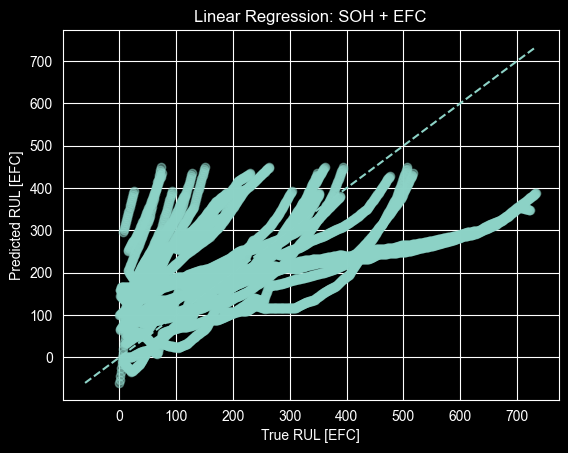

In [33]:
plt.scatter(pred_efc_df["RUL_EFC"], pred_efc_df["RUL_pred"], alpha=0.5)

min_val = min(pred_efc_df["RUL_EFC"].min(), pred_efc_df["RUL_pred"].min())
max_val = max(pred_efc_df["RUL_EFC"].max(), pred_efc_df["RUL_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL [EFC]")
plt.ylabel("Predicted RUL [EFC]")
plt.title("Linear Regression: SOH + EFC")
plt.show()

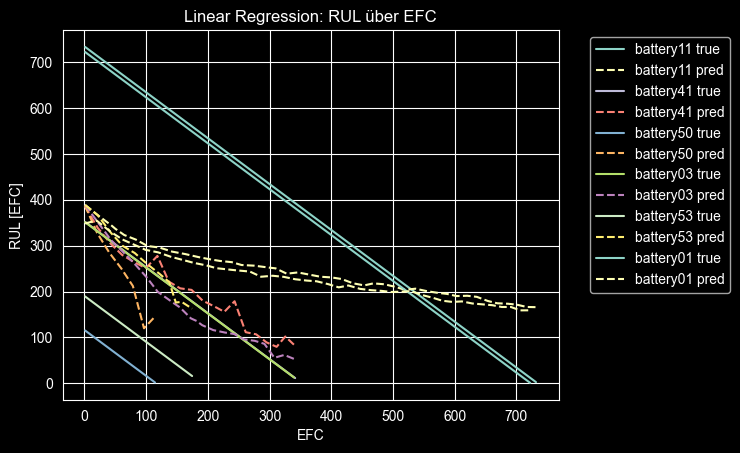

In [34]:
for batt in pred_efc_df["batt_label"].unique()[:6]:
    group = pred_efc_df[pred_efc_df["batt_label"] == batt].copy()
    group = group.sort_values("EFC")

    plt.plot(group["EFC"], group["RUL_EFC"], label=f"{batt} true")
    plt.plot(group["EFC"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("Linear Regression: RUL über EFC")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## RUL-Modell auf regular_alt_batteries


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
df = pd.read_csv("data_complete.csv")

print(df.shape)
df.head()

(7955, 61)


,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cum_avg,...,SOH,SOH(-30EFC),SOH(-60EFC),SOH(-90EFC),SOH(-120EFC),delta_SOH(-30EFC),delta_SOH(-60EFC),delta_SOH(-90EFC),delta_SOH(-120EFC),RUL_EFC
0,battery00,True,7424.475,1.001191,17.149865,0.035325,0.189894,0.278888,0.400940,26.569209,...,100.000000,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,0.000000,150.411108
1,battery00,False,12219.679,1.995107,32.833935,0.038305,0.190357,0.282313,0.403624,32.363611,...,99.788050,100.0,100.0,100.0,100.0,0.211950,0.211950,0.211950,0.211950,149.417193
2,battery00,False,17025.679,2.992049,48.630552,0.041295,0.190822,0.285749,0.406316,35.243437,...,99.575454,100.0,100.0,100.0,100.0,0.424546,0.424546,0.424546,0.424546,148.420251
3,battery00,False,21836.339,3.987183,64.388980,0.044280,0.191287,0.289179,0.409004,36.865746,...,99.363243,100.0,100.0,100.0,100.0,0.636757,0.636757,0.636757,0.636757,147.425116
4,battery00,False,29014.698,4.976644,79.798714,0.047247,0.191748,0.292589,0.411676,34.856287,...,99.152243,100.0,100.0,100.0,100.0,0.847757,0.847757,0.847757,0.847757,146.435656


In [37]:
# Regular ALT batteries auswählen
# Diese Batterien besitzen konstante Entladeströme und sind deshalb
# ein methodisch sauberer Startpunkt für das RUL-Modell.

regular_batteries = [
    "battery00", "battery01",
    "battery10", "battery11",
    "battery20", "battery21", "battery22", "battery23",
    "battery30", "battery31",
    "battery40", "battery41",
    "battery50", "battery51", "battery52"
]

df_regular = df[df["batt_label"].isin(regular_batteries)].copy()

print(df_regular.shape)
print(df_regular["batt_label"].unique())

(4537, 61)
['battery00' 'battery01' 'battery10' 'battery11' 'battery20' 'battery21'
 'battery22' 'battery23' 'battery30' 'battery31' 'battery40' 'battery41'
 'battery50' 'battery51' 'battery52']


In [38]:
# Relevante Spalten prüfen

df_regular[["batt_label", "EFC", "SOH", "C_rate_cycle_max", "RUL_EFC"]].head()

,batt_label,EFC,SOH,C_rate_cycle_max,RUL_EFC
0,battery00,1.001191,100.000000,1.029796,150.411108
1,battery00,1.995107,99.788050,6.684085,149.417193
2,battery00,2.992049,99.575454,6.680648,148.420251
3,battery00,3.987183,99.363243,6.682063,147.425116
4,battery00,4.976644,99.152243,7.914710,146.435656


In [39]:
# Fehlende Werte in den relevanten Spalten prüfen

df_regular[["SOH", "EFC", "C_rate_cycle_max", "RUL_EFC"]].isna().sum()

SOH                 0
EFC                 0
C_rate_cycle_max    0
RUL_EFC             0
dtype: int64

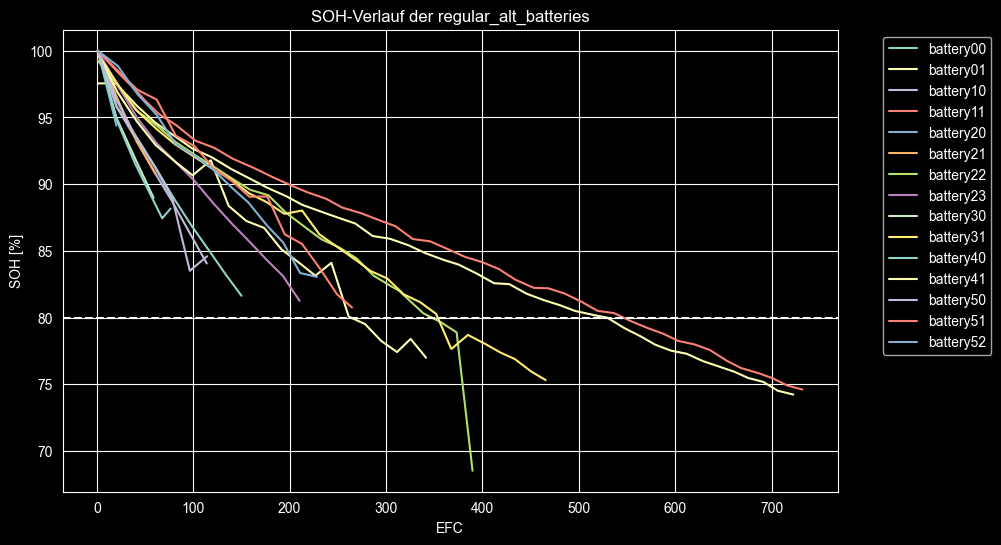

In [40]:
# SOH-Verlauf über EFC für regular_alt_batteries


plt.figure(figsize=(10, 6))

for batt, group in df_regular.groupby("batt_label"):
    group = group.sort_values("EFC")
    plt.plot(group["EFC"], group["SOH"], label=batt)

plt.axhline(80, linestyle="--")
plt.xlabel("EFC")
plt.ylabel("SOH [%]")
plt.title("SOH-Verlauf der regular_alt_batteries")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

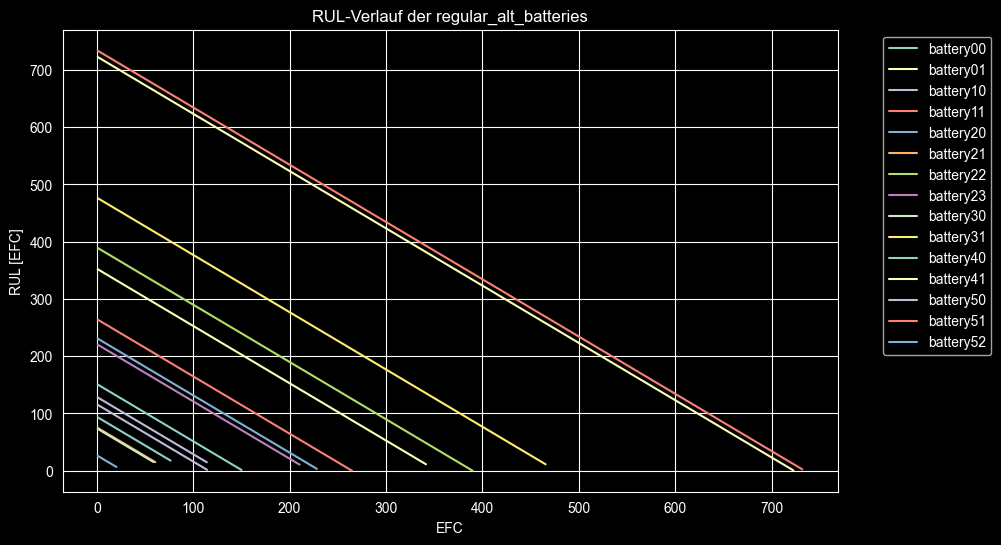

In [41]:
# RUL-Verlauf über EFC für regular_alt_batteries


plt.figure(figsize=(10, 6))

for batt, group in df_regular.groupby("batt_label"):
    group = group.sort_values("EFC")
    plt.plot(group["EFC"], group["RUL_EFC"], label=batt)

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("RUL-Verlauf der regular_alt_batteries")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [42]:
# ML-Datensatz erstellen


feature_cols = ["SOH", "C_rate_cycle_max"]

df_ml_regular = df_regular[["batt_label", "EFC", "RUL_EFC"] + feature_cols].copy()
df_ml_regular = df_ml_regular.dropna()

X = df_ml_regular[feature_cols]   # EFC ist NICHT im Modell
y = df_ml_regular["RUL_EFC"]
groups = df_ml_regular["batt_label"]

In [43]:
# Lineare Regression mit batteriegetrenntem GroupKFold


gkf = GroupKFold(n_splits=4)

results_regular = []
predictions_regular = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_batteries = df_ml_regular.iloc[test_idx]["batt_label"].unique().tolist()

    results_regular.append({
        "feature_set": "SOH + C_rate_cycle_max",
        "model": "LinearRegression",
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": test_batteries
    })

    fold_pred = df_ml_regular.iloc[test_idx].copy()
    fold_pred["fold"] = fold
    fold_pred["RUL_pred"] = y_pred
    predictions_regular.append(fold_pred)

results_regular_df = pd.DataFrame(results_regular)
pred_regular_df = pd.concat(predictions_regular, ignore_index=True)

results_regular_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,SOH + C_rate_cycle_max,LinearRegression,0,122.322881,151.660776,0.532013,"[battery10, battery11, battery50]"
1,SOH + C_rate_cycle_max,LinearRegression,1,123.669904,153.992073,0.504118,"[battery00, battery01, battery20, battery40]"
2,SOH + C_rate_cycle_max,LinearRegression,2,79.959032,118.027129,0.065405,"[battery21, battery23, battery31, battery51]"
3,SOH + C_rate_cycle_max,LinearRegression,3,89.853202,131.197347,-0.608226,"[battery22, battery30, battery41, battery52]"


In [44]:
# Mittlere Modellgüte über alle Folds

results_regular_df[["MAE", "RMSE", "R2"]].mean()

MAE     103.951255
RMSE    138.719331
R2        0.123328
dtype: float64

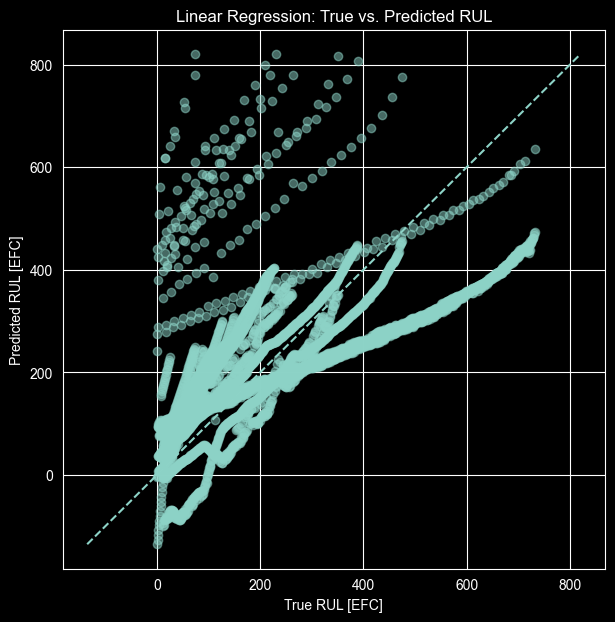

In [45]:
# True vs. Predicted RUL


plt.figure(figsize=(7, 7))

plt.scatter(pred_regular_df["RUL_EFC"], pred_regular_df["RUL_pred"], alpha=0.5)

min_val = min(pred_regular_df["RUL_EFC"].min(), pred_regular_df["RUL_pred"].min())
max_val = max(pred_regular_df["RUL_EFC"].max(), pred_regular_df["RUL_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL [EFC]")
plt.ylabel("Predicted RUL [EFC]")
plt.title("Linear Regression: True vs. Predicted RUL")
plt.show()

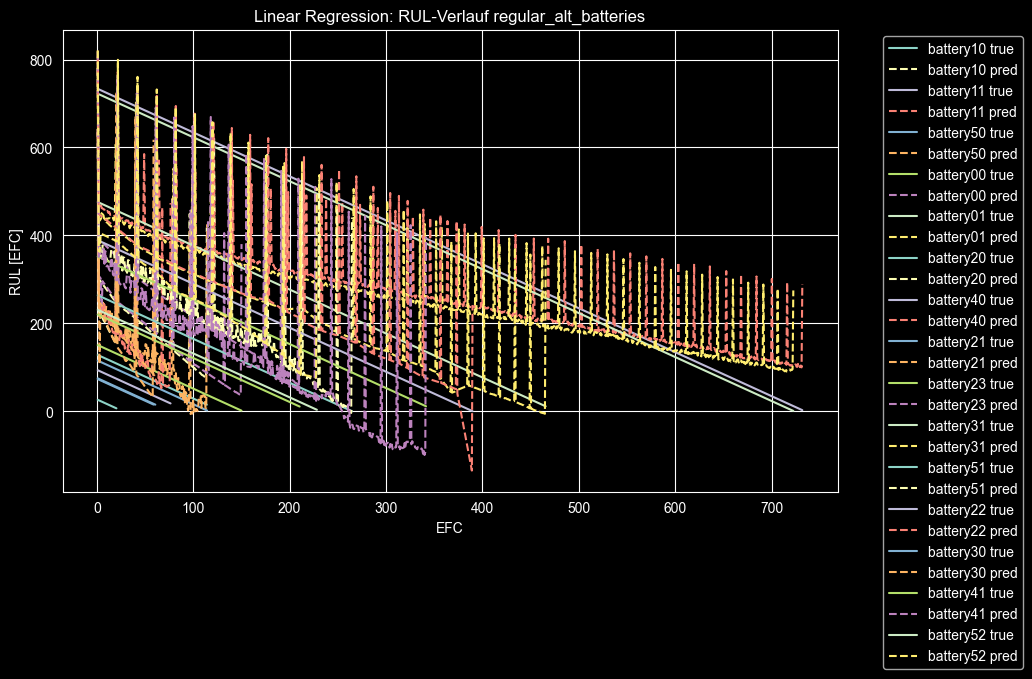

In [46]:
# RUL-Verlauf: echte vs. vorhergesagte Werte


plt.figure(figsize=(10, 6))

for batt in pred_regular_df["batt_label"].unique():
    group = pred_regular_df[pred_regular_df["batt_label"] == batt].copy()
    group = group.sort_values("EFC") if "EFC" in group.columns else group.sort_values("SOH")

    if "EFC" in group.columns:
        plt.plot(group["EFC"], group["RUL_EFC"], label=f"{batt} true")
        plt.plot(group["EFC"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")
    else:
        plt.plot(group["SOH"], group["RUL_EFC"], label=f"{batt} true")
        plt.plot(group["SOH"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("Linear Regression: RUL-Verlauf regular_alt_batteries")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Fazit

Für das erste RUL-Modell wurden nur die regular_alt_batteries verwendet, da diese konstante Entladeströme besitzen und damit einen methodisch sauberen Startpunkt darstellen.

Als Features wurden SOH und C_rate_cycle_max verwendet. Die Zielvariable ist RUL_EFC.

Die Validierung wurde batteriegetrennt mit GroupKFold durchgeführt, sodass keine Batterie gleichzeitig in Trainings- und Testdaten vorkommt.

## C_rate_cycle_avg als Feature


In [47]:
# Prüfen, wie die Referenzzyklen codiert sind
df_regular["isRefCycle"].value_counts()

isRefCycle
False    4305
True      232
Name: count, dtype: int64

In [52]:
# ============================================================
# Lineare Regression: SOH + C_rate_cycle_avg
# regular_alt_batteries ohne Referenzzyklen
# ============================================================

# Referenzzyklen entfernen
df_regular_no_ref = df_regular[df_regular["isRefCycle"] == 0].copy()

# Features definieren
feature_cols = ["SOH", "C_rate_cycle_avg"]

# ML-Datensatz bauen
# EFC wird nur für spätere Plots mitgenommen, aber NICHT als Feature verwendet
df_ml_regular_no_ref = df_regular_no_ref[
    ["batt_label", "EFC", "RUL_EFC"] + feature_cols
].copy()

df_ml_regular_no_ref = df_ml_regular_no_ref.dropna()

X = df_ml_regular_no_ref[feature_cols]
y = df_ml_regular_no_ref["RUL_EFC"]
groups = df_ml_regular_no_ref["batt_label"]

# GroupKFold: ganze Batterien bleiben zusammen
gkf = GroupKFold(n_splits=4)

results_regular_no_ref = []
predictions_regular_no_ref = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_batteries = df_ml_regular_no_ref.iloc[test_idx]["batt_label"].unique().tolist()

    results_regular_no_ref.append({
        "feature_set": "SOH + C_rate_cycle_avg, no ref cycles",
        "model": "LinearRegression",
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "test_batteries": test_batteries
    })

    fold_pred = df_ml_regular_no_ref.iloc[test_idx].copy()
    fold_pred["fold"] = fold
    fold_pred["RUL_pred"] = y_pred
    predictions_regular_no_ref.append(fold_pred)

results_regular_no_ref_df = pd.DataFrame(results_regular_no_ref)
pred_regular_no_ref_df = pd.concat(predictions_regular_no_ref, ignore_index=True)

results_regular_no_ref_df

,feature_set,model,fold,MAE,RMSE,R2,test_batteries
0,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,0,70.504913,82.215260,0.862160,"[battery00, battery11, battery20, battery40]"
1,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,1,75.023317,86.831987,0.842193,"[battery01, battery10, battery50]"
2,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,2,65.380165,75.200477,0.619431,"[battery21, battery23, battery31, battery51]"
3,"SOH + C_rate_cycle_avg, no ref cycles",LinearRegression,3,67.794140,88.682583,0.261938,"[battery22, battery30, battery41, battery52]"


In [53]:
results_regular_no_ref_df[["MAE", "RMSE", "R2"]].mean()

MAE     69.675634
RMSE    83.232577
R2       0.646430
dtype: float64

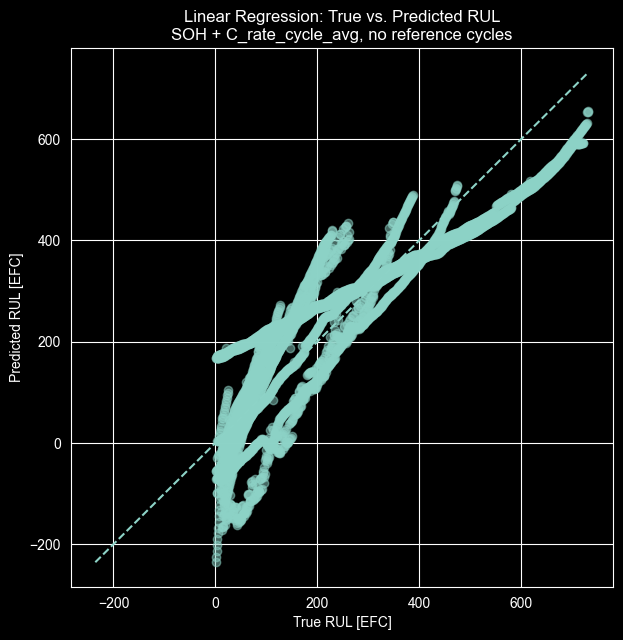

In [54]:
# ============================================================
# True vs. Predicted RUL
# Modell: SOH + C_rate_cycle_avg, ohne Referenzzyklen
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    pred_regular_no_ref_df["RUL_EFC"],
    pred_regular_no_ref_df["RUL_pred"],
    alpha=0.5
)

min_val = min(
    pred_regular_no_ref_df["RUL_EFC"].min(),
    pred_regular_no_ref_df["RUL_pred"].min()
)

max_val = max(
    pred_regular_no_ref_df["RUL_EFC"].max(),
    pred_regular_no_ref_df["RUL_pred"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL [EFC]")
plt.ylabel("Predicted RUL [EFC]")
plt.title("Linear Regression: True vs. Predicted RUL\nSOH + C_rate_cycle_avg, no reference cycles")
plt.show()

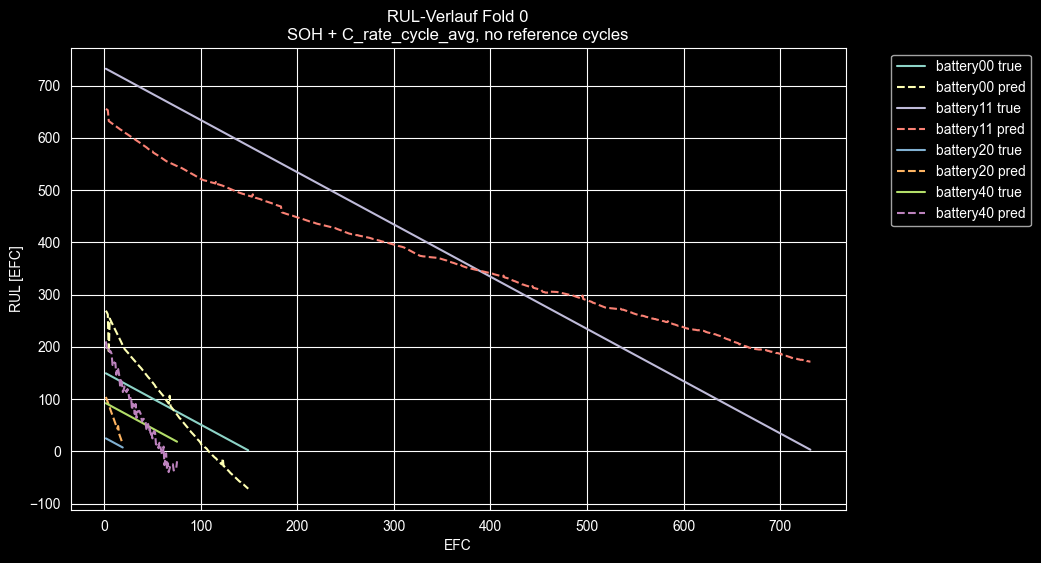

In [55]:
# ============================================================
# RUL-Verlauf: echte vs. vorhergesagte Werte
# Nur ein Fold, damit der Plot lesbar bleibt
# ============================================================

fold_to_plot = 0

plot_df = pred_regular_no_ref_df[
    pred_regular_no_ref_df["fold"] == fold_to_plot
].copy()

plt.figure(figsize=(10, 6))

for batt in plot_df["batt_label"].unique():
    group = plot_df[plot_df["batt_label"] == batt].copy()
    group = group.sort_values("EFC")

    plt.plot(group["EFC"], group["RUL_EFC"], label=f"{batt} true")
    plt.plot(group["EFC"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title(f"RUL-Verlauf Fold {fold_to_plot}\nSOH + C_rate_cycle_avg, no reference cycles")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

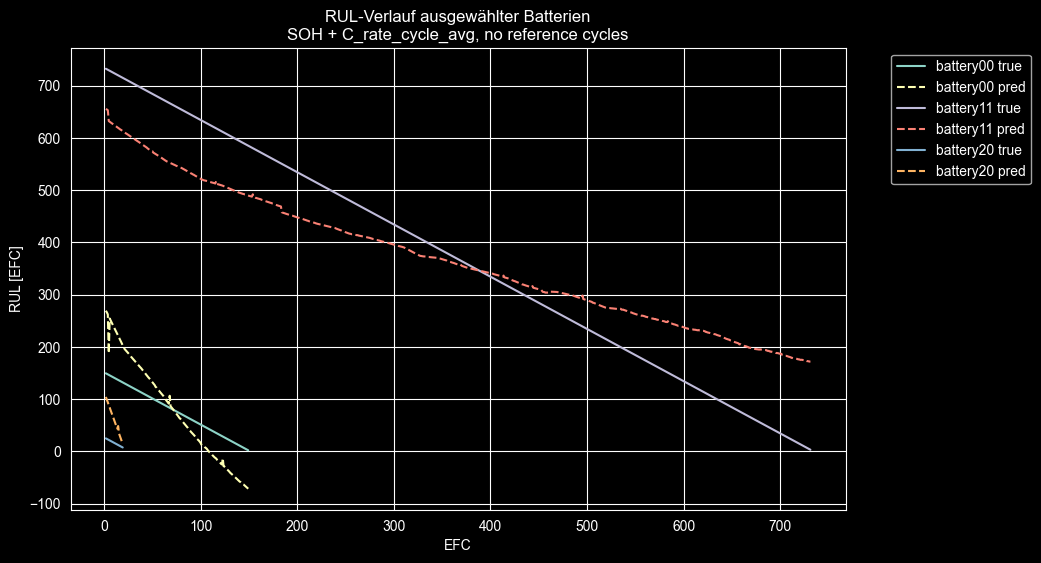

In [56]:
# ============================================================
# RUL-Verlauf: ausgewählte Batterien
# ============================================================

selected_batteries = pred_regular_no_ref_df["batt_label"].unique()[:3]

plot_df = pred_regular_no_ref_df[
    pred_regular_no_ref_df["batt_label"].isin(selected_batteries)
].copy()

plt.figure(figsize=(10, 6))

for batt in selected_batteries:
    group = plot_df[plot_df["batt_label"] == batt].copy()
    group = group.sort_values("EFC")

    plt.plot(group["EFC"], group["RUL_EFC"], label=f"{batt} true")
    plt.plot(group["EFC"], group["RUL_pred"], linestyle="--", label=f"{batt} pred")

plt.xlabel("EFC")
plt.ylabel("RUL [EFC]")
plt.title("RUL-Verlauf ausgewählter Batterien\nSOH + C_rate_cycle_avg, no reference cycles")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

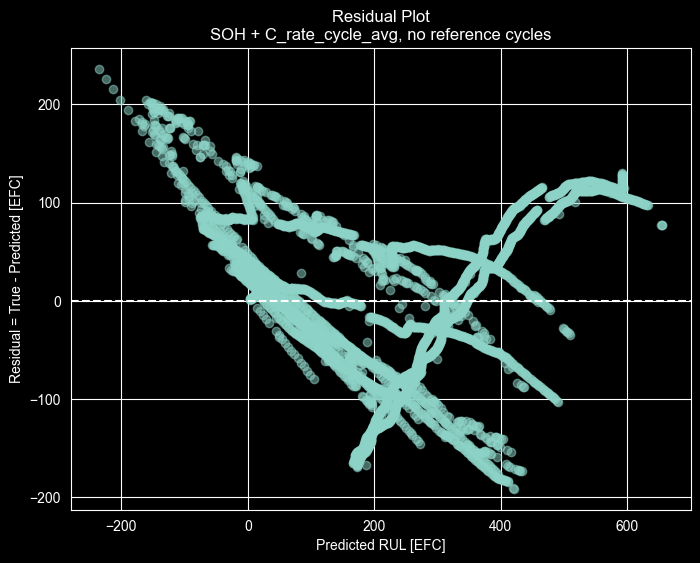

In [57]:
# ============================================================
# Residual Plot
# ============================================================

pred_regular_no_ref_df["Residual"] = (
    pred_regular_no_ref_df["RUL_EFC"] - pred_regular_no_ref_df["RUL_pred"]
)

plt.figure(figsize=(8, 6))

plt.scatter(
    pred_regular_no_ref_df["RUL_pred"],
    pred_regular_no_ref_df["Residual"],
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted RUL [EFC]")
plt.ylabel("Residual = True - Predicted [EFC]")
plt.title("Residual Plot\nSOH + C_rate_cycle_avg, no reference cycles")
plt.show()

## Fazit

Für das erste RUL-Modell wurden die regular_alt_batteries verwendet, da diese konstante Entladeströme besitzen. Da C_rate_cycle_avg als Feature genutzt wird, wurden Referenzzyklen aus dem Datensatz entfernt, um das normale Lastprofil nicht durch Referenzentladungen zu verfälschen.

Das lineare Modell verwendet SOH und C_rate_cycle_avg zur Vorhersage von RUL_EFC. Die batteriegetrennte GroupKFold-Validierung ergibt einen mittleren MAE von ca. 70 EFC, einen RMSE von ca. 83 EFC und ein R² von ca. 0.65.

Damit ist die Modellqualität deutlich besser als bei den vorherigen Baselines. Trotzdem zeigen die Residuen, dass systematische Abweichungen bestehen. Als nächster Schritt könnten weitere zyklusbasierte Features wie Temperaturmerkmale oder kumulierte C-Rate-Features ergänzt werden.